In [18]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

In [19]:
df = pd.read_csv('heart_disease.csv') 

In [20]:
df.head()
df.describe()
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [21]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [22]:
df.drop(["ca", "thal"], axis=1, inplace=True)

In [23]:
numerical_columns = ["trestbps", "chol", "thalch", "oldpeak"]

for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

In [24]:
categorical_columns = ["fbs", "restecg", "exang", "slope"]

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [25]:
df.isnull().sum()

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
num         0
dtype: int64

In [26]:
df["num"] = df["num"].apply(lambda x: 0 if x == 0 else 1)

In [27]:
print(df["num"].value_counts())

num
1    509
0    411
Name: count, dtype: int64


In [28]:
le = LabelEncoder()

categorical_columns = [
    "sex",
    "dataset",
    "cp",
    "restecg",
    "fbs",
    "exang",
    "slope"
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [29]:
print(df.head())

   id  age  sex  dataset  cp  trestbps   chol  fbs  restecg  thalch  exang  \
0   1   63    1        0   3     145.0  233.0    1        0   150.0      0   
1   2   67    1        0   0     160.0  286.0    0        0   108.0      1   
2   3   67    1        0   0     120.0  229.0    0        0   129.0      1   
3   4   37    1        0   2     130.0  250.0    0        1   187.0      0   
4   5   41    0        0   1     130.0  204.0    0        0   172.0      0   

   oldpeak  slope  num  
0      2.3      0    0  
1      1.5      1    1  
2      2.6      1    1  
3      3.5      0    0  
4      1.4      2    0  


In [30]:
X = df.drop(["id", "dataset", "num"], axis=1)

y = df["num"]

In [31]:
print(X.head())

print(y.head())

   age  sex  cp  trestbps   chol  fbs  restecg  thalch  exang  oldpeak  slope
0   63    1   3     145.0  233.0    1        0   150.0      0      2.3      0
1   67    1   0     160.0  286.0    0        0   108.0      1      1.5      1
2   67    1   0     120.0  229.0    0        0   129.0      1      2.6      1
3   37    1   2     130.0  250.0    0        1   187.0      0      3.5      0
4   41    0   1     130.0  204.0    0        0   172.0      0      1.4      2
0    0
1    1
2    1
3    0
4    0
Name: num, dtype: int64


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [34]:
y_pred_dt = dt_model.predict(X_test)

In [35]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.782608695652174


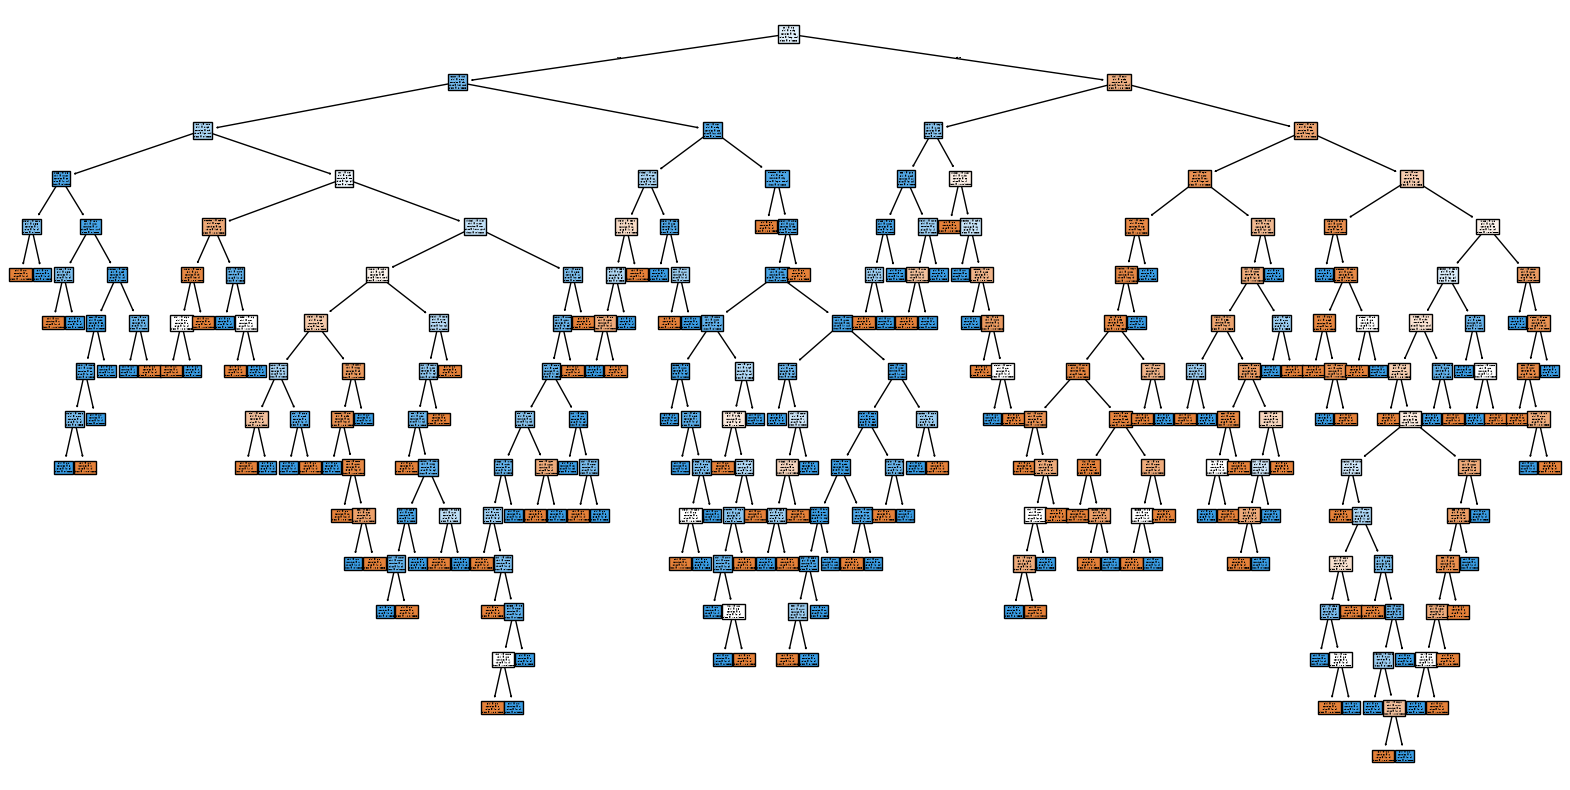

In [36]:
plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True
)

plt.show()

In [37]:
dt_depth = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt_depth.fit(X_train, y_train)

y_pred_depth = dt_depth.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_depth))

Accuracy: 0.7934782608695652


In [38]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [39]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Decision Tree Accuracy:", dt_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Decision Tree Accuracy: 0.782608695652174
Random Forest Accuracy: 0.8152173913043478


In [40]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

     Feature  Importance
2         cp    0.167901
4       chol    0.161032
7     thalch    0.135463
9    oldpeak    0.123036
0        age    0.114490
3   trestbps    0.090895
8      exang    0.078491
1        sex    0.056223
6    restecg    0.031205
10     slope    0.027243
5        fbs    0.014022


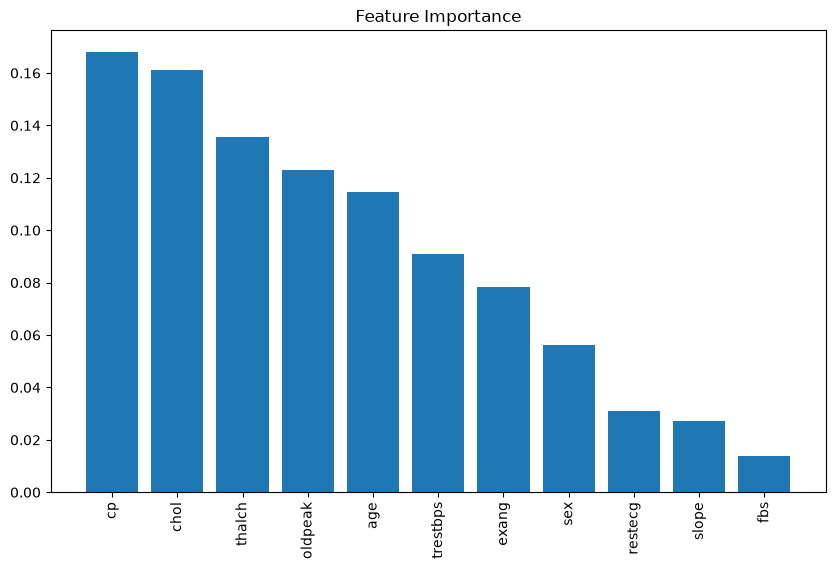

In [41]:
plt.figure(figsize=(10,6))

plt.bar(importance["Feature"], importance["Importance"])

plt.xticks(rotation=90)

plt.title("Feature Importance")

plt.show()

In [42]:
scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5
)

print("Cross-validation scores:", scores)

print("Average accuracy:", scores.mean())

Cross-validation scores: [0.72826087 0.72282609 0.82608696 0.82608696 0.64130435]
Average accuracy: 0.7489130434782609
